# Xi Line Chart

Plot `xi`, `xi_dir`, or `xi_amp` for all countries as thin transparent gray lines, with optional highlighted countries in thicker color.

In [105]:
from pathlib import Path
import os
import sys
import importlib

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from io_networks.config import load_config
import io_networks.viz_xi as viz_xi
importlib.reload(viz_xi)

load_xi_data = viz_xi.load_xi_data
plot_xi_country_lines = viz_xi.plot_xi_country_lines
select_phase_map_countries = viz_xi.select_phase_map_countries
plot_xi_phase_map = viz_xi.plot_xi_phase_map

import matplotlib.pyplot as plt

In [106]:
cfg = load_config('config/default.yaml')
variant = None  # None -> inferred from config (regular/extended)
metric = 'share'  # 'xi', 'xi_dir', 'xi_amp', or 'share' (= xi_amp / xi)
yscale = 'linear'  # linear, log, or symlog
highlight_countries = ['USA', 'GBR', 'FRA', 'DEU', 'CAN', 'AUS']
exclude_countries = []  # optional: hide outliers from main panel
label_pad_years = 1.2  # reserve right-side space for direct end labels

In [107]:
df = load_xi_data(cfg=cfg, variant=variant)
print('rows:', len(df))
print('years:', int(df['year'].min()), 'to', int(df['year'].max()))
if 'status' in df.columns:
    print('status counts:', df['status'].value_counts(dropna=False).to_dict())
df_preview = df.copy()
if metric == 'share':
    denom = df_preview['xi'].replace(0.0, float('nan'))
    df_preview['share'] = df_preview['xi_amp'] / denom
print(df_preview[['year', 'country', metric, 'status']].head(10).to_string(index=False))

rows: 2268
years: 1995 to 2022
status counts: {'ok': 2268}
 year country    share status
 1995     AGO 0.566201     ok
 1995     ARE 0.440407     ok
 1995     ARG 0.618019     ok
 1995     AUS 0.654608     ok
 1995     AUT 0.573185     ok
 1995     BEL 0.535668     ok
 1995     BGD 0.415115     ok
 1995     BGR 0.355666     ok
 1995     BLR 0.557699     ok
 1995     BRA 0.434524     ok


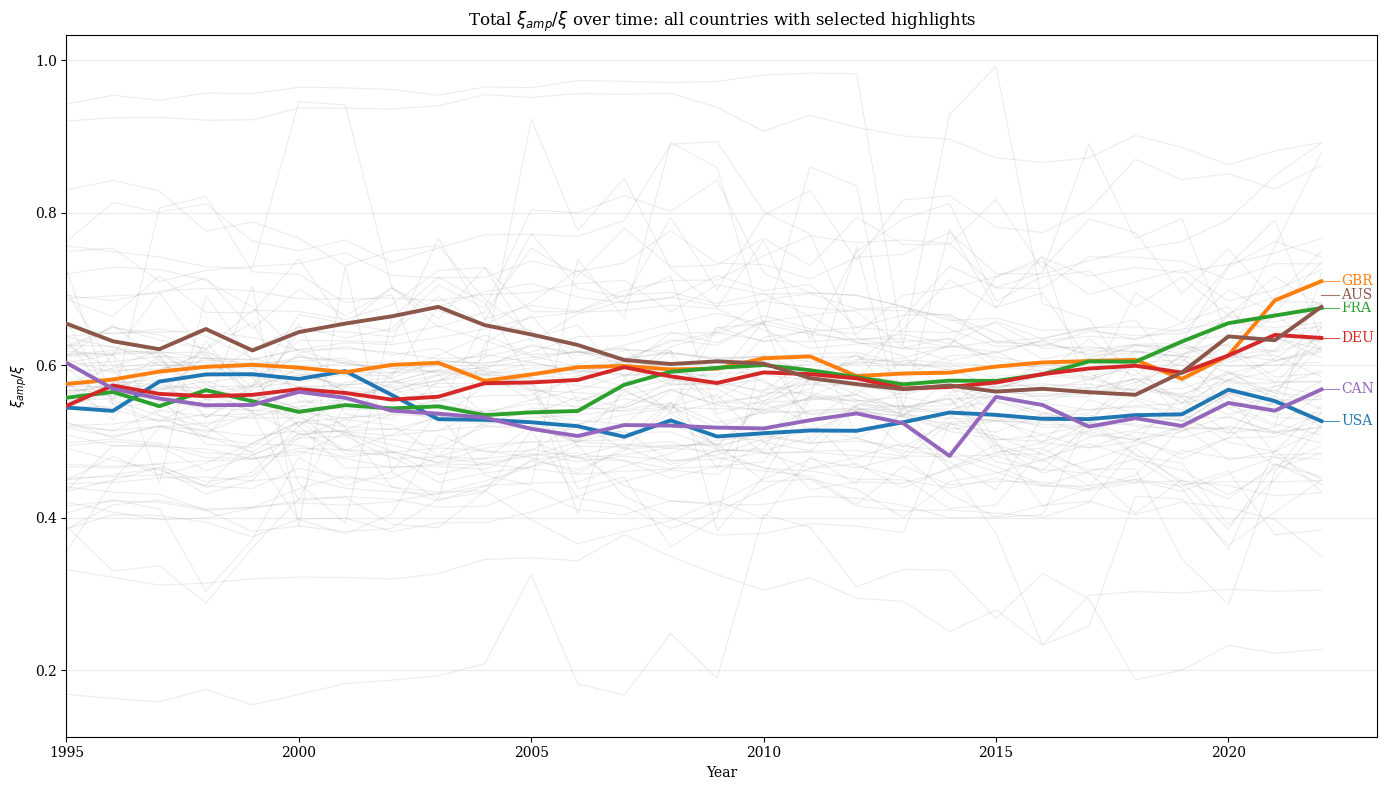

In [108]:
fig, ax = plt.subplots(figsize=(14, 8))
metric_labels = {
    'xi': r'$\xi$',
    'xi_dir': r'$\xi_{dir}$',
    'xi_amp': r'$\xi_{amp}$',
    'share': r'$\xi_{amp} / \xi$',
}
metric_label = metric_labels.get(metric, metric)
plot_xi_country_lines(
    df,
    metric=metric,
    highlight_countries=highlight_countries,
    exclude_countries=exclude_countries,
    only_ok=True,
    yscale=yscale,
    title=rf'Total {metric_label} over time: all countries with selected highlights',
    alpha_bg=0.15,
    lw_bg=0.8,
    lw_hi=2.8,
    use_end_labels=True,
    show_legend=False,
    label_pad_years=label_pad_years,
    ax=ax,
)

#ymin = 0.003
#ymax = 0.10
#ax.set_ylim(ymin, ymax)   # lower, upper

plt.tight_layout()
plt.show()